# Deeptrace Project Task
## Digit Classifier using pytorch and MNIST Dataset

#### Task 1

Loading Imports

In [62]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn  as nn
import matplotlib.pyplot as plt

Loading the Dataset

In [63]:
sampleset = datasets.MNIST(root="data", train=True,download=True)
print(len(sampleset))

60000


In [64]:
print(sampleset)
samples = iter(sampleset)
#print(next(samples))

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train


In [65]:
img,_ =next(samples)
print("Image shape : ", img.size)
#print(sampleset.shape)
print("Dataset shape : ",sampleset.data.shape)

Image shape :  (28, 28)
Dataset shape :  torch.Size([60000, 28, 28])


Visualisation of data

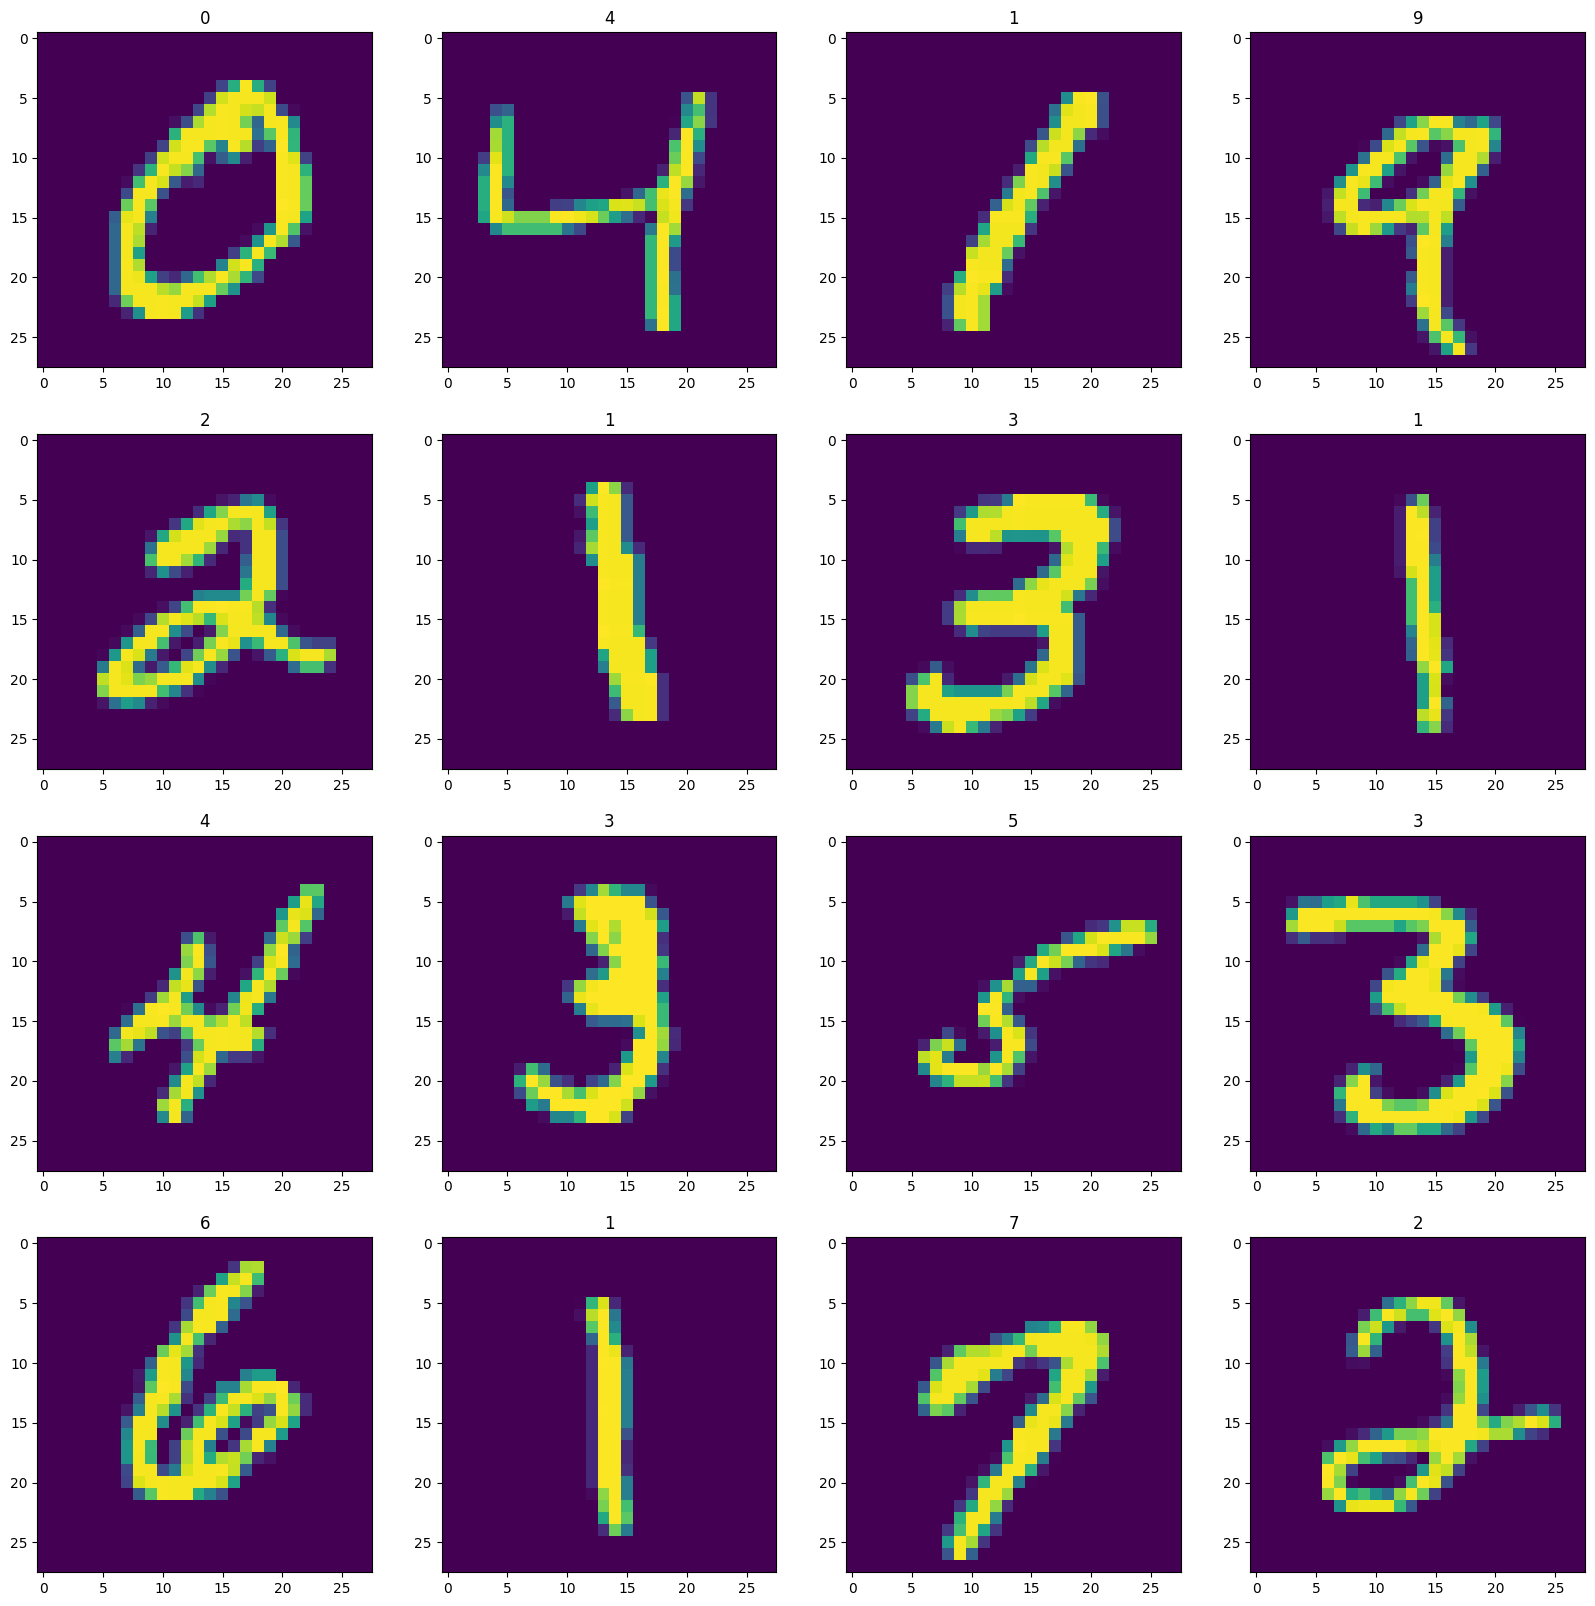

In [66]:

plt.figure(num="Sample Images",figsize=(20,20))
for i in range(1,17):
  plt.subplot(4,4,i)
  img,lbl=next(samples)
  plt.imshow(img)
  plt.title(f"{lbl}", )
plt.show()

#### Task 2

In [67]:
transform = transforms.Compose([
    transforms.RandomAffine(10,scale=(0.8,1.4)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081))
])

In [68]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081))
])

The mean nd standard deviation values for MNIST dataset were found to be 0.1307 and 0.3081 resp [Source](https://community.deeplearning.ai/t/mnist-mean-and-std/883455/4)

In [69]:
trainset = datasets.MNIST(root="data", train=True,transform=transform,download=True)
testset = datasets.MNIST(root="data", train=False,transform=transform_test,download=True)
print(len(trainset))
print(len(testset))

60000
10000


In [70]:
trainloader = DataLoader(trainset, batch_size=64,shuffle=True) #,num_workers=2 if GPU
testloader = DataLoader(testset,batch_size=64) #,num_workers =2 if in GPU

In [71]:
train_samples = iter(trainloader)
img,lbl=next(train_samples)
print(img.shape)
print(lbl.shape)


torch.Size([64, 1, 28, 28])
torch.Size([64])


Task 3

In [72]:
from torch.nn.modules.linear import Linear
from torch.nn.modules.pooling import MaxPool2d
from torch.nn.modules.activation import ReLU
class nnet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(

        nn.Conv2d(1,8,3,1,1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(8,16,3,1,1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Flatten(),
        nn.Linear(16*7*7,10),
        nn.LogSoftmax(dim=1)


    )
  def forward(self,x):
    return self.net(x)


Used 2 convo layers and Relu as activation function and maxpool to shrink size.

In [153]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=nnet().to(device)
print(model)
trainr = iter(trainloader)
img,lbl=next(trainr)
img =img.to(device)
output=model(img)
print(output.shape)



nnet(
  (net): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=784, out_features=10, bias=True)
    (8): LogSoftmax(dim=1)
  )
)
torch.Size([64, 10])


In [74]:
print(lbl.shape)

torch.Size([64])


## Part 2

### Task 1


Defining loss function, optimiser and Learning Rate Scheduler + training loop

In [155]:
criterion = nn.NLLLoss()

optimisr= torch.optim.Adam(model.parameters(),lr=0.005)

lrsch= torch.optim.lr_scheduler.ExponentialLR(optimisr,0.9)

def train():
  count=0
  model.train()
  lossavg=0
  #lavg2=0
  for img ,lbl in trainloader:
      img=img.to(device)
      lbl=lbl.to(device)
      optimisr.zero_grad()
      outputs=model(img)
      loss = criterion(outputs,lbl)
      loss.backward()
      optimisr.step()
      count+=1
      lossavg+=loss.item()
  if count > 0:
    lrsch.step()
    return (lossavg/count)
  print(lossavg," ",count)
  return False



### Task  2

Test function

In [156]:
def test():
  model.eval()
  total=0
  correct=0
  testloss=0
  with torch.no_grad():
    for img,lbl in testloader:
      img=img.to(device)
      lbl=lbl.to(device)
      outputs=model(img)
      loss=criterion(outputs,lbl)
      _,predicted=torch.max(outputs,1)

      testloss+= img.size(0) * loss.item()
      total+=img.size(0)
      correct+= (predicted==lbl).sum().item()
  return (loss/total),(correct/total)
#return training loss : (loss/total)

In [157]:
trloss=[]
ttacc=[]
epochs=[]

In [158]:
for epoch in range(10):
  trnloss = train()
  #lrsch.step()
  testloss,acc = test()
  print("Epoch ", epoch, " : TR Loss : ",trnloss, "   TT Acc : ",acc)
  epochs.append(epoch)
  trloss.append(trnloss)
  ttacc.append(acc)


Epoch  0  : TR Loss :  0.1788119404767352    TT Acc :  0.9836
Epoch  1  : TR Loss :  0.08897895120960007    TT Acc :  0.9873
Epoch  2  : TR Loss :  0.07505346794634053    TT Acc :  0.9851
Epoch  3  : TR Loss :  0.06627940732714183    TT Acc :  0.9887
Epoch  4  : TR Loss :  0.06137483909866139    TT Acc :  0.9888
Epoch  5  : TR Loss :  0.05811427817367184    TT Acc :  0.9891
Epoch  6  : TR Loss :  0.052152604029922466    TT Acc :  0.9892
Epoch  7  : TR Loss :  0.05209388992630505    TT Acc :  0.9888
Epoch  8  : TR Loss :  0.0477139589078635    TT Acc :  0.99
Epoch  9  : TR Loss :  0.046374046450122386    TT Acc :  0.9896


### Task 3



Plotting Training Loss and Test Accuracy vs Epoch

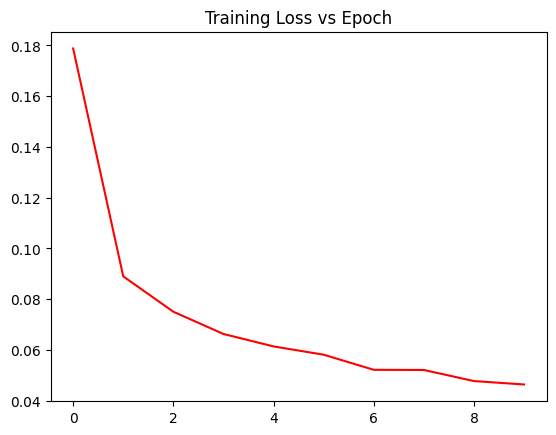

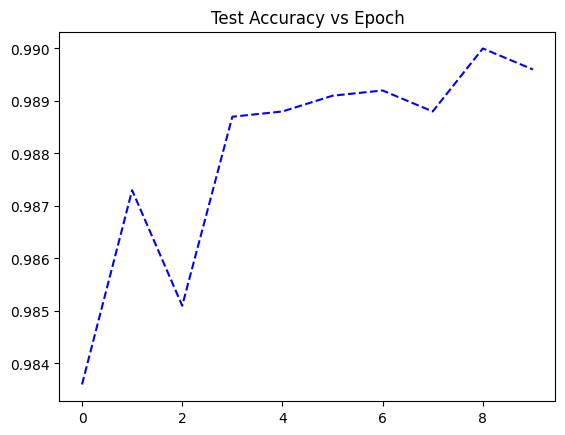

In [159]:
plt.plot(epochs,trloss, color='red',linestyle="-")
plt.title("Training Loss vs Epoch")
plt.show()
plt.plot(epochs,ttacc,color='blue', linestyle="--")
plt.title("Test Accuracy vs Epoch")
plt.show()

Saving the Model

In [146]:
torch.save(model.state_dict(),"model.pt")


In [160]:
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save(model.state_dict(),"/content/drive/MyDrive/model1.pt")

Loading saved model to run inference

In [161]:
model1=nnet()
model1.load_state_dict(torch.load("model.pt"))
model1=model1.to(device)
model1.eval()
trr=iter(testloader)

Run Inference on Sample Image from the testset

In [122]:
img,lbl=next(trr)
img=img.to(device)
lbl=lbl.to(device)
with torch.no_grad():
  outputs=model1(img)
  loss=criterion(outputs,lbl)

  print("Predicted : ",torch.argmax(outputs[0]).item())
  print(f"Confidence in Prediction :{torch.exp(torch.max(outputs[0])).item():.4f} ")
  print("Actual Image : ",lbl[0].item())

Predicted :  8
Confidence in Prediction :1.0000 
Actual Image :  8


For Inference on Custom 28x28 pixels sixed image

Predicted :  7
Confidence in Prediction :0.9351 
tensor([ -4.3243,  -7.8659,  -5.1366,  -5.1657,  -8.5195,  -6.7440, -13.1991,
         -0.0671,  -5.1929,  -3.4181])


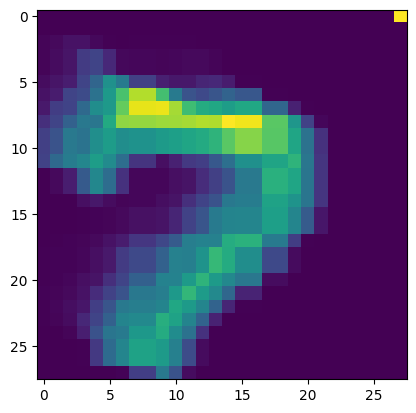

In [126]:
from PIL import Image
model1.eval()
imgpath="somthblur7.png" #replace "somthblur7.png" with image path
customtest=Image.open(imgpath).convert('L')
cus_tst = transform_test(customtest)
cimg=cus_tst.unsqueeze(0)
plt.imshow(customtest)
with torch.no_grad():
  cimg=cimg.to(device)
  outputs=model1(cimg)
  print("Predicted : ",torch.argmax(outputs[0]).item())
  print(f"Confidence in Prediction :{torch.exp(torch.max(outputs[0])).item():.4f} ")
  print(outputs[0])

For confidence(out of 1) for all digits

In [125]:
sum=0
for i,logprb in enumerate(outputs[0]):
  print(i,"  ",torch.exp(logprb).item())
  sum+=torch.exp(logprb).item()
print("Sum : ",sum)

0    0.8695617318153381
1    8.343105582753196e-05
2    0.08360076695680618
3    2.265045441163238e-05
4    6.22385778115131e-06
5    1.1823563909274526e-05
6    0.00012695344048552215
7    3.0662740755360574e-06
8    0.04628947377204895
9    0.00029373864526860416
Sum :  0.9999998598359525


Reflection

The current architecture gives test accuracy around ~99% and a training loss ~0.04.
Batch Normalization,perhaps, could be benificial. For augmentation, RandomAffine(10 degrees) has been used in the current architecture. Further Augmentation of training data by translation, scaling etc might help generalise the training data more better. Experimenting with more Conv layers might be useful.
Tuning the learning rate, batch sizes and other hyperparameters could also, along with other factors, be useful for improving accuracy.